# ML 모델링 프로세스

1. 데이터 수집
2. 전처리 (클렌징에 가까움)
3. 탐색 EDA - 타겟 : 카테고리 > 분류, 숫자 > 회귀
4. 모델 선택
5. 모델 학습
6. 모델 성능 평가
7. 모델 개선 > 3번으로, 4번으로, 5번으로
8. 모델 배포 > ai서버에 로드, 앱도 만들어야 한다

# 데이터 수집

In [157]:
from sklearn.datasets import load_iris
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [158]:
iris_data = iris.data
iris_data.shape #X

(150, 4)

In [159]:
iris_label = iris.target #y=0, 1, 2
iris_label

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

X >> iris_data
y(target) >> iris_label > category (분류모델이 필요)

# 데이터 탐색 > 분할

훈련용 + 테스트용 > 8:2, 7:3

In [160]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_data,
                                                    iris_label,
                                                    test_size = 0.2,
                                                    random_state=42)
X_train.shape, X_test.shape #X의 훈련용, 테스트용 분할 결과

((120, 4), (30, 4))

In [161]:
X_train[:5]

array([[4.6, 3.6, 1. , 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [6.7, 3.1, 4.4, 1.4],
       [4.8, 3.4, 1.6, 0.2],
       [4.4, 3.2, 1.3, 0.2]])

In [162]:
y_train.shape, y_test.shape #y의 훈련용, 테스트용 분할 결과

((120,), (30,))

# 모델 선택 > DecisionTreeClassifier

In [163]:
from sklearn.tree import DecisionTreeClassifier #class: 알고리즘 구현
iris_Dt_clf = DecisionTreeClassifier() #객체생성
iris_Dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# 모델 학습
X, y를 넣어준다. > train을 넣는다. 

In [164]:
iris_Dt_clf.fit(X_train, y_train)
iris_Dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# 모델 평가

In [165]:
iris_pred = iris_Dt_clf.predict(X_test)
iris_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [166]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, iris_pred)

1.0

In [168]:
from sklearn.datasets import load_wine

In [169]:
wine = load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [170]:
wine_data = wine.data
wine_data.shape


(178, 13)

In [171]:
wine_label = wine.target #y=0, 1, 2
wine_label

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [172]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(wine_data,
                                                    wine_label,
                                                    test_size = 0.2
                                                    ,random_state=42
                                                    , stratify=wine_label)
X_train.shape, X_test.shape #X의 훈련용, 테스트용 분할 결과

((142, 13), (36, 13))

In [ ]:
from sklearn.tree import DecisionTreeClassifier #class: 알고리즘 구현
wine_Dt_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
wine_Dt_clf.fit(X_train, y_train)
wine_pred = wine_Dt_clf.predict(X_test)
wine_result = accuracy_score(y_test, wine_pred)

print(f'와인 품종 분류기의 정확도는 {wine_result*100}%입니다')

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [174]:
wine_Dt_clf.fit(X_train, y_train)
wine_Dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [175]:
wine_pred = wine_Dt_clf.predict(X_test)
wine_pred

array([0, 2, 0, 1, 1, 0, 0, 1, 1, 2, 1, 2, 0, 2, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 2, 1, 2, 0, 2, 1, 2, 2, 2])

In [176]:
from sklearn.metrics import accuracy_score
wine_result = accuracy_score(y_test, wine_pred)

print(f'와인 품종 분류기의 정확도는 {wine_result*100}%입니다')

와인 품종 분류기의 정확도는 100.0%입니다


In [167]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, iris_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

In [156]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, wine_pred)

array([[12,  0,  0],
       [ 0, 14,  0],
       [ 0,  0, 10]])

# 프로세스 연습

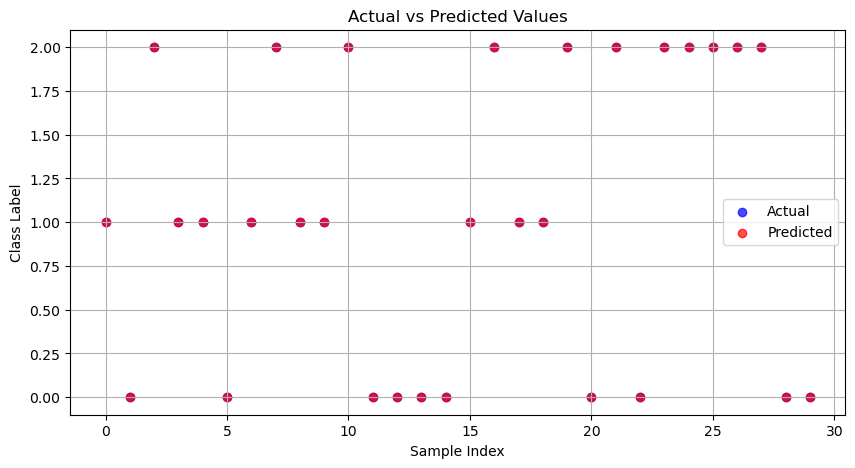

In [143]:
import matplotlib.pyplot as plt

# 샘플 인덱스
x = range(len(y_test))

plt.figure(figsize=(10, 5))

# 실제값
plt.scatter(x, y_test, color='blue', label='Actual', alpha=0.7)

# 예측값
plt.scatter(x, iris_pred, color='red', label='Predicted', alpha=0.7)

plt.xlabel('Sample Index')
plt.ylabel('Class Label')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

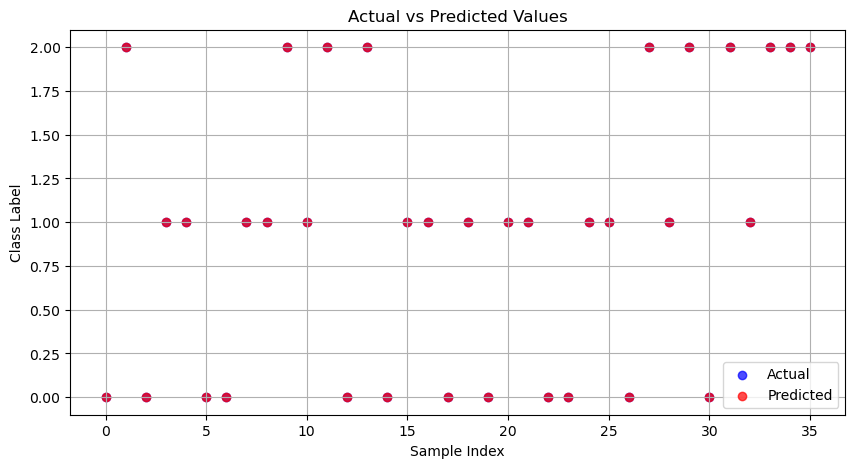

In [177]:
import matplotlib.pyplot as plt

# 샘플 인덱스
x = range(len(y_test))

plt.figure(figsize=(10, 5))

# 실제값
plt.scatter(x, y_test, color='blue', label='Actual', alpha=0.7)

# 예측값
plt.scatter(x, wine_pred, color='red', label='Predicted', alpha=0.7)

plt.xlabel('Sample Index')
plt.ylabel('Class Label')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## 의사결정나무 알고리즘

In [178]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
import graphviz 
from sklearn.tree import export_graphviz

#모델의 트리를 파일로 저장합니다.
export_graphviz(iris_Dt_clf, out_file="iris_tree.dot",
                class_names= iris.target_names)

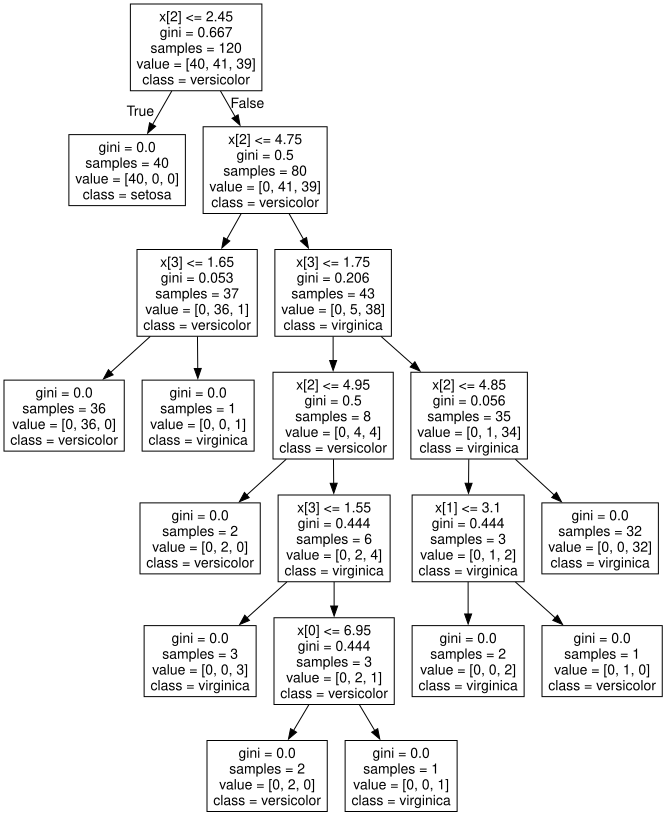

In [182]:
# tree 파일을 읽어옵니다
with open('iris_tree.dot') as f:
  dot_graph = f.read()
  
# 트리를 그립니다  
graphviz.Source(dot_graph)

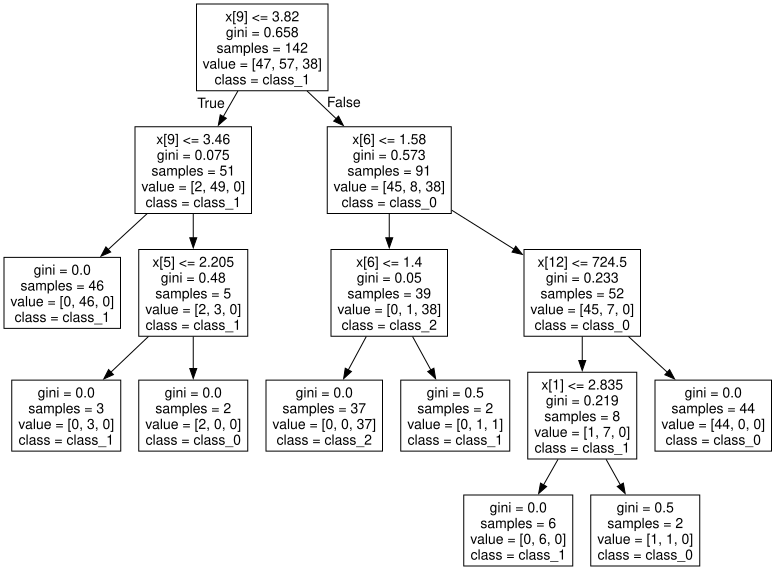

In [183]:
export_graphviz(wine_Dt_clf, out_file="wine_tree.dot",
                class_names= wine.target_names)

with open('wine_tree.dot') as f:
  wine_dot_graph = f.read()
  
graphviz.Source(wine_dot_graph)

# k-fold cross validation (교차검증)

In [184]:
import pandas as pd
iris_data_df = pd.DataFrame(data= iris.data, columns = iris.feature_names)

In [186]:
iris_data_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [187]:
iris_data_df['label'] = iris.target
iris_data_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

In [188]:
from sklearn.model_selection import KFold
kfold_5 = KFold(n_splits=5)
kfold_5

KFold(n_splits=5, random_state=None, shuffle=False)

In [189]:
iris_cv_clf =DecisionTreeClassifier(random_state=42)
iris_cv_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [190]:
for train_index, test_index in kfold_5.split(iris_data):
  X_train, X_test = iris_data[train_index], iris_data[test_index]
  y_train, y_test = iris_label[train_index], iris_label[test_index]
  
  iris_cv_clf.fit(X_train, y_train)
  pred = iris_cv_clf.predict(X_test)
  acc = accuracy_score(y_test, pred)
  print(f'Accuracy : {acc:.4f}')

Accuracy : 1.0000
Accuracy : 1.0000
Accuracy : 0.8333
Accuracy : 0.9333
Accuracy : 0.8000


# cross_val_score()

In [196]:
from sklearn.model_selection import cross_val_score
X = iris.data
y = iris.target
iris_Dt_clf_cv = DecisionTreeClassifier(random_state=156)
cross_val_score(iris_Dt_clf_cv, X, y, cv=5, scoring='accuracy')

array([0.96666667, 0.96666667, 0.9       , 0.96666667, 1.        ])

In [197]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5)
cross_val_score(iris_Dt_clf_cv, X, y, cv=skf, scoring='accuracy')

array([0.96666667, 0.96666667, 0.9       , 0.96666667, 1.        ])

In [194]:
from sklearn.model_selection import cross_val_score
X = wine.data
y = wine.target
wine_Dt_clf_cv = DecisionTreeClassifier(random_state=156)
cross_val_score(wine_Dt_clf_cv, X, y, cv=5, scoring='accuracy')

array([0.94444444, 0.80555556, 0.86111111, 0.91428571, 0.85714286])

In [195]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5)
cross_val_score(wine_Dt_clf_cv, X, y, cv=skf, scoring='accuracy')

array([0.94444444, 0.80555556, 0.86111111, 0.91428571, 0.85714286])

# GridSearchCV

In [198]:
from sklearn.model_selection import GridSearchCV
iris_Dt_gcv = DecisionTreeClassifier(random_state=121)
params = {'max_depth':[1,2,3], 'min_samples_split':[2,3]}
grid_dt_cv = GridSearchCV(iris_Dt_gcv, cv=5, param_grid=params)
grid_dt_cv.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=121)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...], 'min_samples_split': [2, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

# wine data로 데이터스케일링

In [201]:
wine = load_wine()
wine_df = pd.DataFrame(data= wine.data, columns= wine.feature_names)
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [202]:
wine_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

In [205]:
wine_df['target'] = wine.target
wine_df['target'].value_counts().sort_index

<bound method Series.sort_index of target
1    71
0    59
2    48
Name: count, dtype: int64>

# LogisticRegression

In [207]:
X = wine.data
y = wine.target

In [209]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=11)
X_train.shape ,X_test.shape ,y_train.shape ,y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [215]:
from sklearn.linear_model import LogisticRegression
wine_lr_clf = LogisticRegression(max_iter=100)
wine_lr_clf.fit(X_train, y_train) 
wine_lr_pred = wine_lr_clf.predict(X_test)
accuracy_score(y_test, wine_lr_pred)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9722222222222222

# 스케일링 후

In [216]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [217]:
from sklearn.linear_model import LogisticRegression
wine_lr_clf_scaled = LogisticRegression(max_iter=100)
wine_lr_clf_scaled.fit(X_train_scaled, y_train) 
wine_lr_pred_scaled = wine_lr_clf_scaled.predict(X_test_scaled)
accuracy_score(y_test, wine_lr_pred_scaled)

1.0

In [222]:
from sklearn.tree import DecisionTreeClassifier #class: 알고리즘 구현
wine_Dt_clf = DecisionTreeClassifier(
    criterion="gini",
)
wine_Dt_clf.fit(X_train, y_train)
wine_pred = wine_Dt_clf.predict(X_test)
wine_result = accuracy_score(y_test, wine_pred)

print(f'와인 품종 분류기의 정확도는 {wine_result*100}%입니다')

와인 품종 분류기의 정확도는 97.22222222222221%입니다


In [220]:
from sklearn.tree import DecisionTreeClassifier #class: 알고리즘 구현
wine_Dt_clf = DecisionTreeClassifier(
    criterion="gini",
)
wine_Dt_clf.fit(X_train_scaled, y_train)
wine_pred = wine_Dt_clf.predict(X_test_scaled)
wine_result = accuracy_score(y_test, wine_pred)

print(f'와인 품종 분류기의 정확도는 {wine_result*100}%입니다')

와인 품종 분류기의 정확도는 94.44444444444444%입니다


모델링 프로세스는 동일하다.
- 각 모델의 하이퍼파라미터가 다르다. 

In [224]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


models = {
  'KNN' : KNeighborsClassifier(),
  'RF'  : RandomForestClassifier(),
  'LR'  : LogisticRegression()
}
for name, model in models.items(): 
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  print( f'{name} 모델의 정확도: {accuracy_score(y_test, y_pred):.5f}')

KNN 모델의 정확도: 1.00000
RF 모델의 정확도: 0.97222
LR 모델의 정확도: 1.00000


In [225]:
models = {
  'KNN': KNeighborsClassifier(
      n_neighbors=5,
      weights='distance'
  ),
  'RF': RandomForestClassifier(
      n_estimators=200,
      max_depth=5,
      min_samples_split=4,
      min_samples_leaf=2,
      random_state=42
  ),
  'LR': LogisticRegression(
      penalty='l2',
      C=1.0,
      solver='lbfgs',
      max_iter=2000
  )
}

for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  print(f'{name} 모델의 정확도: {accuracy_score(y_test, y_pred):.5f}')

KNN 모델의 정확도: 1.00000
RF 모델의 정확도: 1.00000
LR 모델의 정확도: 1.00000


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [226]:
import numpy as np

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# -------------------------
# 1) CV 설정 (계층적 분할)
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------
# 2) 모델별 Pipeline + param_grid
#    (스케일 필요한 모델: KNN/LR)
# -------------------------
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

param_knn = {
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],  # 1=manhattan, 2=euclidean
}

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

param_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],  # l2 + 다중분류 안정
}

# RF는 스케일링 불필요 → 스케일러 없이
pipe_rf = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

param_rf = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [None, 3, 5, 8],
    "model__min_samples_split": [2, 4, 8],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

# -------------------------
# 3) GridSearchCV 실행 (각 모델)
# -------------------------
searches = {
    "KNN": (pipe_knn, param_knn),
    "LR":  (pipe_lr,  param_lr),
    "RF":  (pipe_rf,  param_rf),
}

best_models = {}
for name, (pipe, grid) in searches.items():
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1,
        verbose=0,
        refit=True
    )
    gs.fit(X_train, y_train)

    best_models[name] = gs
    print(f"\n[{name}]")
    print("Best CV accuracy:", gs.best_score_)
    print("Best params:", gs.best_params_)

# -------------------------
# 4) 최고 모델 선택 후 테스트셋 평가
# -------------------------
best_name = max(best_models, key=lambda k: best_models[k].best_score_)
best_gs = best_models[best_name]

print(f"\n🏆 Best model by CV: {best_name}")
y_pred = best_gs.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


[KNN]
Best CV accuracy: 0.9578817733990148
Best params: {'model__n_neighbors': 7, 'model__p': 1, 'model__weights': 'uniform'}

[LR]
Best CV accuracy: 0.9790640394088669
Best params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



[RF]
Best CV accuracy: 0.9788177339901478
Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

🏆 Best model by CV: LR
Test accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         7

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [227]:
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    HistGradientBoostingClassifier, BaggingClassifier,
    VotingClassifier, StackingClassifier
)

# -------------------------------------------------
# (0) 예시: split (이미 되어 있으면 이 블록은 생략)
# -------------------------------------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=42
# )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------------------------------
# (1) Base models (스케일 필요한 애들은 Pipeline)
# -------------------------------------------------
lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

svc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, C=3, gamma="scale"))
])

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7, weights="distance"))
])

dt = DecisionTreeClassifier(max_depth=4, random_state=42)

# -------------------------------------------------
# (2) Bagging / Randomization ensembles
# -------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300, max_depth=6,
    min_samples_leaf=2, random_state=42
)

extra = ExtraTreesClassifier(
    n_estimators=500, max_depth=None,
    min_samples_leaf=1, random_state=42
)

bag_dt = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=300,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    random_state=42
)

# -------------------------------------------------
# (3) Boosting ensembles
# -------------------------------------------------
gboost = GradientBoostingClassifier(random_state=42)

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42),
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

hgb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

# -------------------------------------------------
# (4) XGBoost (설치되어 있으면 사용, 없으면 스킵)
# -------------------------------------------------
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    )
except Exception as e:
    xgb = None

# -------------------------------------------------
# (5) Voting / Stacking
# -------------------------------------------------
voting_soft = VotingClassifier(
    estimators=[("lr", lr), ("svc", svc), ("knn", knn)],
    voting="soft"
)

stacking = StackingClassifier(
    estimators=[("rf", rf), ("svc", svc), ("knn", knn)],
    final_estimator=LogisticRegression(max_iter=5000),
    passthrough=False,
    cv=cv
)

# -------------------------------------------------
# (6) 한 번에 비교 (CV 평균 + Test accuracy)
# -------------------------------------------------
models = {
    "LR": lr,
    "SVC": svc,
    "KNN": knn,
    "RF": rf,
    "ExtraTrees": extra,
    "Bagging(DT)": bag_dt,
    "GradientBoost": gboost,
    "AdaBoost": adaboost,
    "HistGradientBoost": hgb,
    "Voting(soft)": voting_soft,
    "Stacking": stacking,
}

if xgb is not None:
    models["XGBoost"] = xgb
else:
    print("※ xgboost가 설치되어 있지 않아 XGBoost 모델은 제외했어. (pip install xgboost)")

results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append((name, cv_scores.mean(), cv_scores.std(), accuracy_score(y_test, pred)))

# 정렬 출력 (CV mean 기준)
results.sort(key=lambda x: x[1], reverse=True)

print("\n=== Model Comparison ===")
for name, mean_cv, std_cv, test_acc in results:
    print(f"{name:14s} | CV acc: {mean_cv:.4f} ± {std_cv:.4f} | Test acc: {test_acc:.4f}")

# 최고 모델 리포트
best_name = results[0][0]
best_model = models[best_name]
best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

print(f"\n🏆 Best (by CV mean): {best_name}")
print("Test accuracy:", accuracy_score(y_test, best_pred))
print("\nClassification report:\n", classification_report(y_test, best_pred))


=== Model Comparison ===
ExtraTrees     | CV acc: 0.9860 ± 0.0172 | Test acc: 1.0000
Stacking       | CV acc: 0.9788 ± 0.0173 | Test acc: 1.0000
LR             | CV acc: 0.9719 ± 0.0259 | Test acc: 1.0000
RF             | CV acc: 0.9717 ± 0.0142 | Test acc: 0.9722
Voting(soft)   | CV acc: 0.9648 ± 0.0218 | Test acc: 1.0000
SVC            | CV acc: 0.9645 ± 0.0226 | Test acc: 1.0000
XGBoost        | CV acc: 0.9645 ± 0.0319 | Test acc: 0.9722
HistGradientBoost | CV acc: 0.9576 ± 0.0145 | Test acc: 1.0000
Bagging(DT)    | CV acc: 0.9574 ± 0.0268 | Test acc: 0.9722
AdaBoost       | CV acc: 0.9505 ± 0.0282 | Test acc: 0.9722
KNN            | CV acc: 0.9438 ± 0.0275 | Test acc: 1.0000
GradientBoost  | CV acc: 0.9155 ± 0.0171 | Test acc: 0.9722

🏆 Best (by CV mean): ExtraTrees
Test accuracy: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        15
           